Preprocessing: Spike cleaning and peak-to-peak thresholding available. \
Analysis: PCA for keypoint data and for ECoG data available. \
Plotting: Spectrogram, morlet scalogram, spatial data plotting available. \

Will add: velocity data for keypoints, RRR function

In [ ]:
!git clone https://github.com/mserhat1/NMA_Project.git
import sys
sys.path.append('/content/NMA_Project')

In [ ]:
%cd NMA_Project
!pip install -r requirements.txt

Choose subject and session

In [3]:
from functions.data import get_datafile

sbj = 10
session = 3

nwbfile = get_datafile(sbj=sbj, session=session)

/usr/local/lib/python3.11/dist-packages/hdmf/spec/namespace.py:583: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
ndx-events - cached version: 0.2.0, loaded version: 0.2.1
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)


Extract spatial data

In [55]:
from functions.data import extract_spatial_data

spatial_data = extract_spatial_data(nwbfile)

stacked_spatial = windowed_spatial(spatial_data, time_window)

Plot spatial data

In [ ]:
from functions.plotting import plot_spatial_data

keypoints = ['R_Wrist', 'L_Wrist', 'R_Shoulder', 'L_Shoulder', 'R_Elbow', 'L_Elbow', 'R_Ear', 'L_Ear', 'Nose']
time_window = 'all'

# If time_window is 'all', it shows you the entire data.
# If you want a specific time window, uncomment the line below and adjust the interval.
time_window = (55000, 56500)

plot_spatial_data(spatial_data, keypoints, time_window=time_window, plot_histogram=True)

Apply PCA over time-series data from keypoints

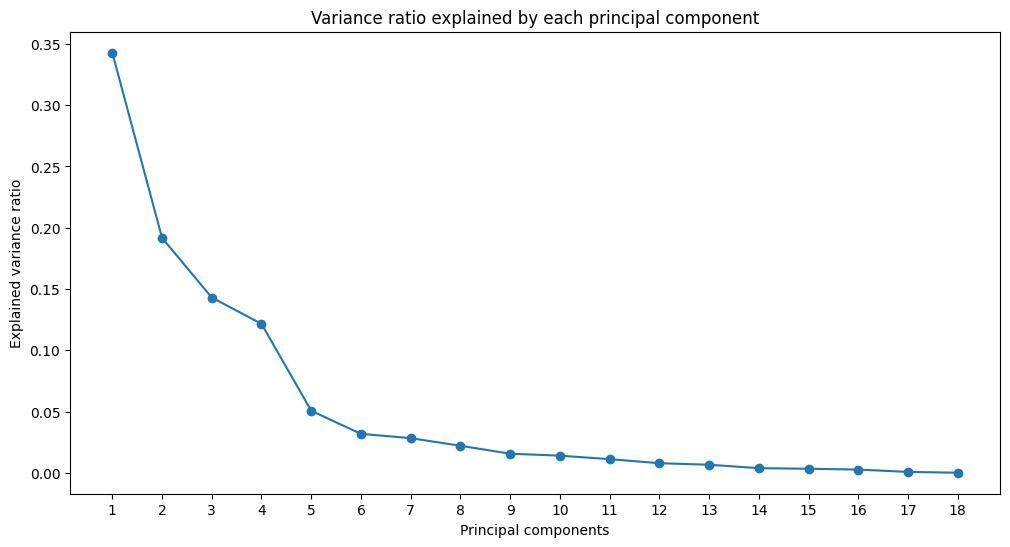

In [13]:
from functions.analysis import keypoints_pca

spatial_pca = keypoints_pca(spatial_data, time_window=(55000, 56500), plot=True)

In [15]:
# Seems like 4 PC's is a good choice in this case.
chosen_pcs = 4

kp_data = pc_data['kp_data']
pcs = pc_data['components'] # (n_components, n_features)
top_pcs = pcs[:chosen_pcs, :]

print(top_pcs.shape, kp_data.shape)
projected_spatial = kp_data @ top_pcs.T

print(projected_spatial.shape) # (n_samples, n_components)

(4, 18) (45000, 18)
(45000, 4)


Extract neural data

In [8]:
from functions.data import extract_neural_data

# specify parameters
channel = 'all'
time_window = (55000, 56500)

ecog_data = extract_neural_data(nwbfile, channel=channel, time_window=time_window)

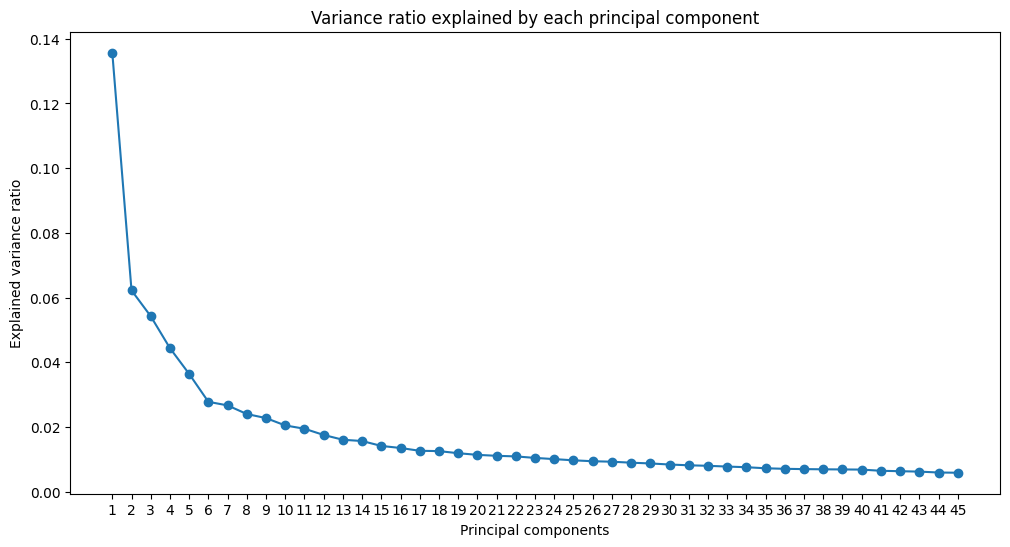

In [25]:
from functions.analysis import ecog_pca

neural_pca = ecog_pca(ecog_data, time_window=(55000, 56500), n_components=0.80, plot=True)

In [23]:
chosen_pcs = 6
neural_data = neural_pca['kp_data']
pcs = neural_pca['components'] # (n_components, n_features)
top_pcs = pcs[:chosen_pcs, :]

print(top_pcs.shape, neural_data.shape)
projected_neural = neural_data @ top_pcs.T

print(projected_neural.shape) # (n_samples, n_components)

(6, 126) (750000, 126)
(750000, 6)


In [24]:
print(projected_spatial.shape)
print(projected_neural.shape)

(45000, 4)
(750000, 6)


In [31]:
import numpy as np
from scipy.interpolate import interp1d

def time_interpolate(spatial, neural, kind='linear'):
    n_original = spatial.shape[0]
    n_target = neural.shape[0]

    x_original = np.linspace(0, 1, n_original)
    x_new = np.linspace(0, 1, n_target)

    interpolated_data = np.empty((n_target, spatial.shape[1]))

    for i in range(spatial.shape[1]):
        f = interp1d(x_original, spatial[:, i], kind=kind)  # or 'cubic'
        interpolated_data[:, i] = f(x_new)

    return interpolated_data

In [35]:
spatial_interp = time_interpolate(projected_spatial, projected_neural)

(750000, 4)


In [33]:
from functions.model import RRR

A, C = RRR(spatial_interp, projected_neural)

In [34]:
print(A)
print(C)

[[ 2.50733322e-03  1.32019259e-03  2.14700361e-03 -2.96060755e-04]
 [-3.70991400e-03 -5.48702133e-03  1.37085412e-03  6.47431065e-04]
 [ 5.99894601e-03  2.45936013e-03  4.46409620e-05  1.51113486e-03]
 [-1.09051079e-02  5.39815421e-03  6.94344771e-04  4.40127446e-04]]
[[-0.80641494  0.27565283 -0.09358089 -0.25222538]
 [ 0.28000761  0.49801226 -0.81134578 -0.09739336]
 [-0.25592043 -0.77393926 -0.548364   -0.10046528]
 [-0.15945894 -0.01343024 -0.13185699  0.85229615]
 [-0.39316432  0.24765204  0.0663308  -0.0104816 ]
 [ 0.16059289 -0.12452077  0.10233045 -0.43621671]]


In [ ]:
from functions.plotting_new import plot_signal

# don't use the whole time window for plotting, it will take forever.
plot_signal(ecog_data)

Apply further preprocessing

In [ ]:
from functions.preprocessing import spike_cleaning

clean_data = spike_cleaning(ecog_data, mode='interp')

In [ ]:
from functions.plotting_new import plot_spectrogram, plot_morlet
# NOTE: These functions work only for single channel ecog_data, for more channels they will give an error!

# computes spectrogram for each time epoch around the event, then averages across epochs
# specify parameters
plot_spectrogram(clean_data, lower_freq=70, upper_freq=150, nperseg=256)

# complex morlet wavelet transform, baseline corrected with z-score (per epoch),
# I will include the option to apply baseline correction after averaging the
# transforms as well.
# specify parameters
plot_morlet(clean_data, lower_freq=1, upper_freq=60, B=4, C=10)